In [8]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from itertools import combinations
import sys
sys.path.append('..')

from src.process_features_angles import JOINT_ANGLE_COLUMNS, ABDUCTION_ANGLE_COLUMNS, PINCH_ANGLE_COLUMNS
from src.process_features_distances import TIP_TO_WRIST_COLUMNS, TIP_TO_THUMB_COLUMNS, PIP_TO_WRIST_COLUMNS, MCP_TO_WRIST_COLUMNS

FEATURE_GROUPS_ANGLES = {
    "Joint": JOINT_ANGLE_COLUMNS,
    "Abduction": ABDUCTION_ANGLE_COLUMNS,
    "Pinch": PINCH_ANGLE_COLUMNS,
}

FEATURE_GROUPS_DISTANCES = {
    "Tip_Wrist": TIP_TO_WRIST_COLUMNS,
    "Tip_Thumb": TIP_TO_THUMB_COLUMNS,
    "Pip_Wrist": PIP_TO_WRIST_COLUMNS,
    "Mcp_Wrist": MCP_TO_WRIST_COLUMNS,
}

FEATURE_GROUPS_ANGLES_n_DISTANCES = {
    **FEATURE_GROUPS_ANGLES,
    **FEATURE_GROUPS_DISTANCES,
}

df_fa = pd.read_csv('../data/processed/featured_angles.csv').dropna()
df_fd = pd.read_csv('../data/processed/featured_distances.csv').dropna()
df_fad = pd.concat([df_fa, df_fd.drop(columns="label")], axis=1)

In [9]:
def plot_pca(df, feature_columns, title):
    X = df[feature_columns]
    y = df["label"]

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(6,6))

    for label in sorted(y.unique()):
        mask = y == label
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=label,
            alpha=0.7
        )

    explained_variance = pca.explained_variance_ratio_.sum()

    plt.title(f"{title}\nExplained variance = {explained_variance:.2%}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.show()

    return explained_variance

In [10]:
def evaluate_feature_groups(df, feature_groups):
    group_names = list(feature_groups.keys())
    results = []

    for r in range(1, len(group_names) + 1):
        for combo in combinations(group_names, r):

            columns = []
            for group in combo:
                columns.extend(feature_groups[group])

            explained_variance = plot_pca(df=df, feature_columns=columns, title=" + ".join(combo))
            results.append({"features": " + ".join(combo), "n_features": len(columns), "explained_variance": explained_variance})
    return pd.DataFrame(results)

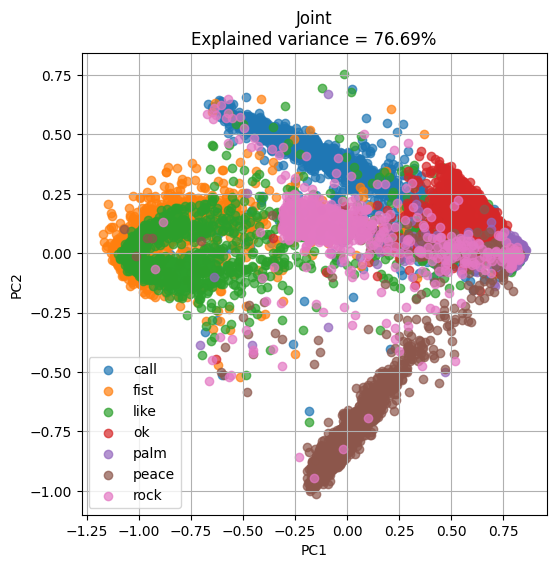

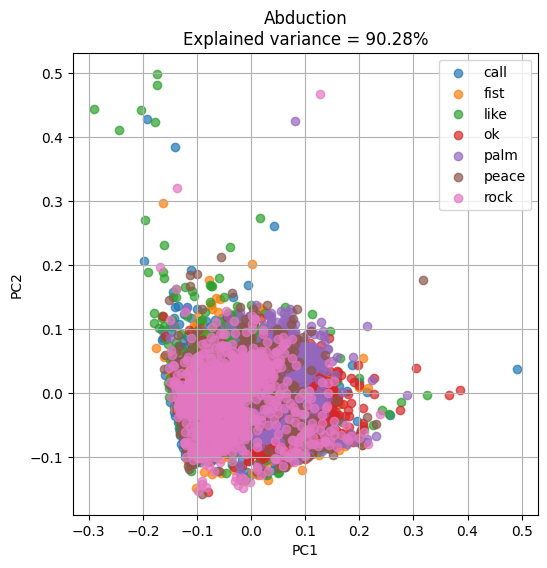

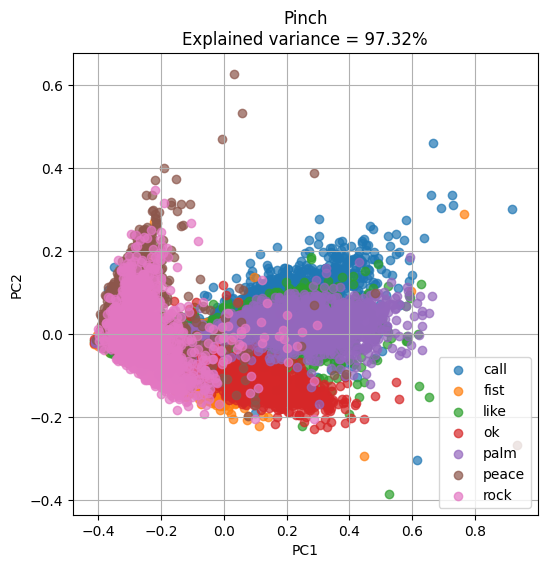

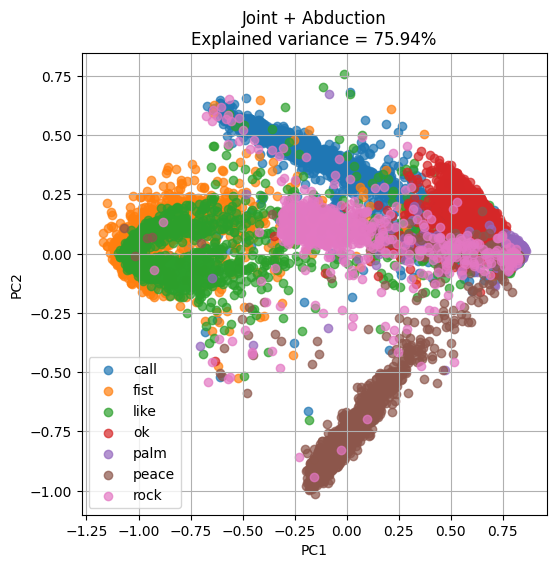

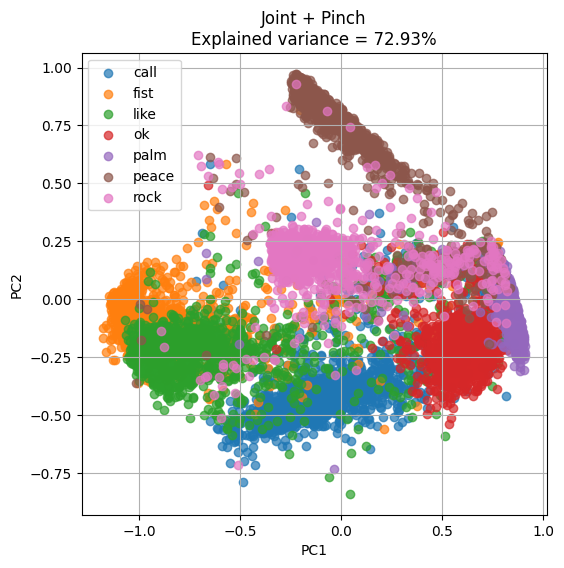

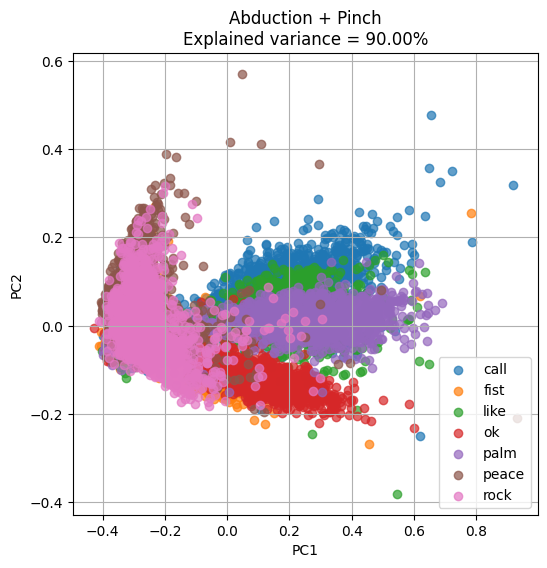

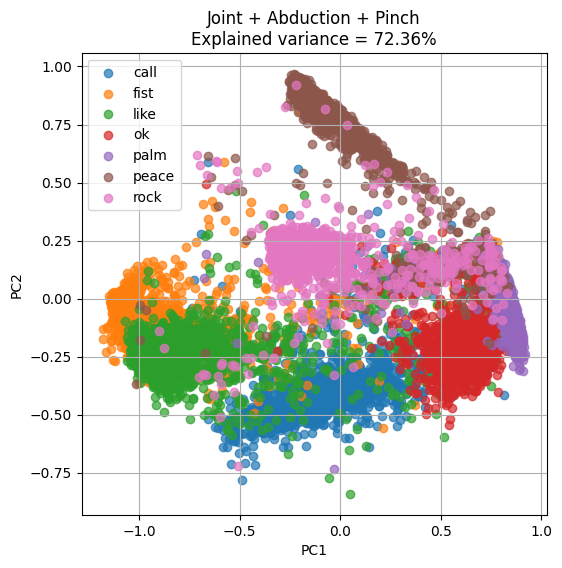

,features,n_features,explained_variance
2,Pinch,4,0.973170
1,Abduction,4,0.902825
5,Abduction + Pinch,8,0.899996
0,Joint,11,0.766898
3,Joint + Abduction,15,0.759447
4,Joint + Pinch,15,0.729331
6,Joint + Abduction + Pinch,19,0.723619


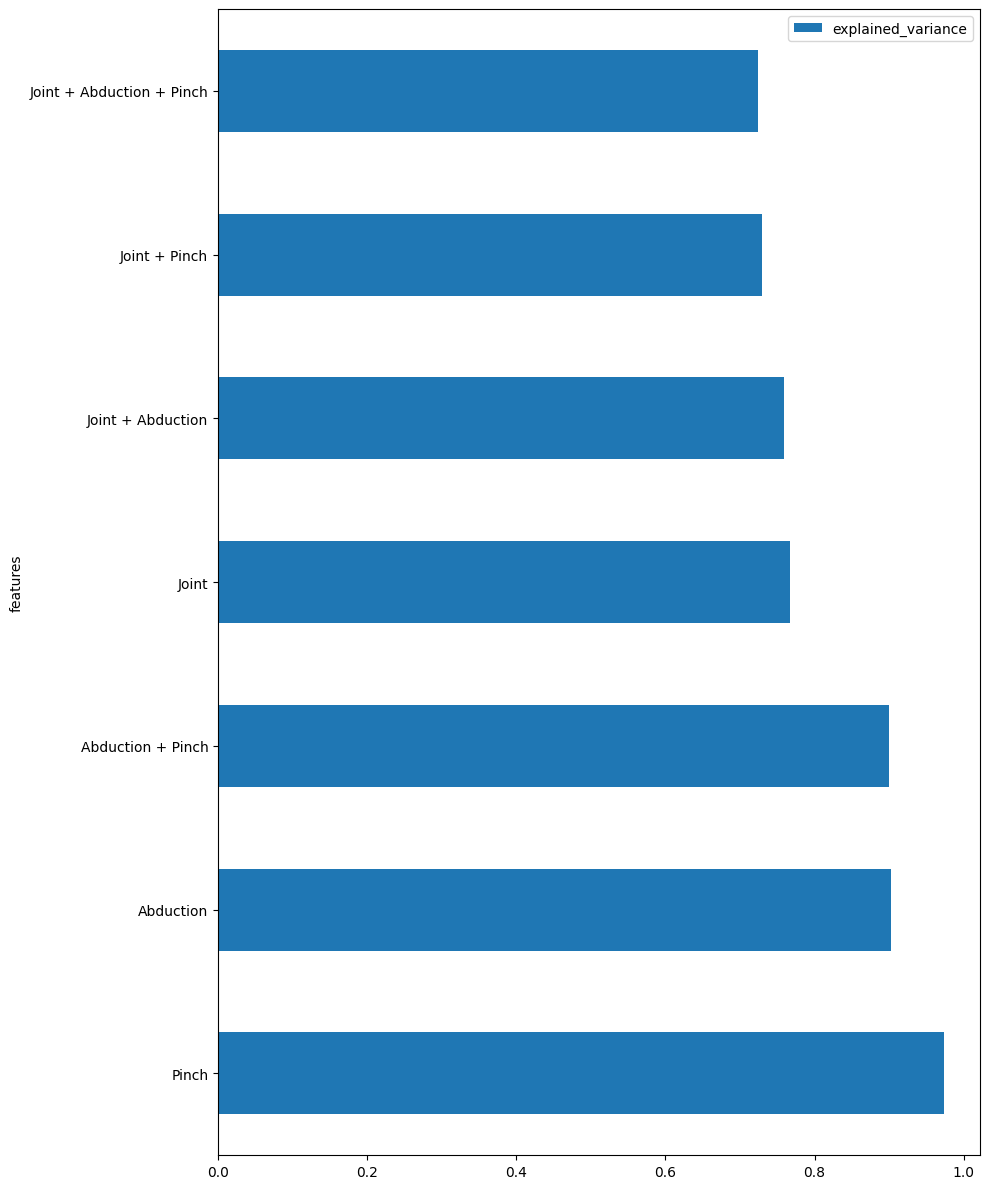

In [11]:
results = evaluate_feature_groups(df_fa, FEATURE_GROUPS_ANGLES)
#results = evaluate_feature_groups(df_fd, FEATURE_GROUPS_DISTANCES)
#results = evaluate_feature_groups(df_fad, FEATURE_GROUPS_ANGLES_n_DISTANCES)

results_sorted = results.sort_values("explained_variance", ascending=False)
display(results_sorted)
results_sorted.plot(x="features", y="explained_variance", kind="barh", figsize=(10, 12))
plt.tight_layout()
plt.show()